In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

In [28]:
df = pd.read_csv("student_performance.csv")

df.head()


,Student_ID,Study_Hours,Attendance,Assignment_Score,Exam_Score
0,STU001,9.5,95.0,92.0,32.0
1,STU002,9.6,68.0,70.2,88.2
2,STU003,7.9,80.6,81.8,83.1
3,STU004,6.8,83.7,82.6,77.5
4,STU005,3.2,61.9,62.1,44.0


Activities

Task 1: Descriptive Statistics

In [29]:
#df['Exam_Score'].value_counts()


In [30]:
mean_scr=df['Exam_Score'].mean()
median_scr=df['Exam_Score'].median()
mode_scr=df['Exam_Score'].mode()[0]
var_scr = df['Exam_Score'].var()
std_scr = df['Exam_Score'].std()

In [31]:
print("--- Task 1: Descriptive Statistics ---")
print(f"Mean Score: {mean_scr:.2f}")
print(f"Median Score: {median_scr:.2f}")
print(f"Mode Score: {mode_scr}")
print(f"Variance: {var_scr:.2f}")
print(f"Standard Deviation: {std_scr:.2f}\n")

--- Task 1: Descriptive Statistics ---
Mean Score: 67.06
Median Score: 68.40
Mode Score: 70.3
Variance: 207.91
Standard Deviation: 14.42



Task 2: Percentiles and Quartiles

In [32]:
# Gives all percentiles and min,max values at once
#print(df['Exam_Score'].describe())


In [33]:
q1 = df['Exam_Score'].quantile(0.25)
q2 = df['Exam_Score'].quantile(0.50)
q3 = df['Exam_Score'].quantile(0.75)
min_score = df['Exam_Score'].min()
max_score = df['Exam_Score'].max()

print("--- Task 2: Percentiles & Quartiles ---")
print(f"Minimum: {min_score}")
print(f"25th Percentile (Q1): {q1:.2f}")
print(f"50th Percentile (Q2/Median): {q2:.2f}")
print(f"75th Percentile (Q3): {q3:.2f}")
print(f"Maximum: {max_score}")
print(f"Middle 50% Score Range: Between {q1:.2f} and {q3:.2f}\n")

--- Task 2: Percentiles & Quartiles ---
Minimum: 32.0
25th Percentile (Q1): 58.30
50th Percentile (Q2/Median): 68.40
75th Percentile (Q3): 77.50
Maximum: 94.1
Middle 50% Score Range: Between 58.30 and 77.50



Task 3: Correlation Analysis

In [34]:
# Remove all hidden spaces or extra spaces
df.columns = df.columns.str.strip()

corr_study=df['Study_Hours'].corr(df['Exam_Score'])
corr_Att = df['Attendance'].corr(df['Exam_Score'])

corr_Assig=df['Assignment_Score'].corr(df['Exam_Score'])

print("--- Task 3: Correlation Analysis ---")

print(f"Study Hours VS Exam Score : {corr_study:.2f}")
print(f"Attendance vs Exam Score: {corr_Att:.2f}")
print(f"Assignment Score vs Exam Score: {corr_Assig:.2f}\n")

--- Task 3: Correlation Analysis ---
Study Hours VS Exam Score : 0.59
Attendance vs Exam Score: -0.14
Assignment Score vs Exam Score: 0.08



In [35]:
plt.figure(figsize=(6,4))
plt.scatter(df['Study_Hours'],df['Exam_Score'],color="red",edgecolors='k')
plt.title('Highest Correlation: Study Hours vs Exam Score')
plt.xlabel('Studt_Hours')
plt.ylabel('Exam_Score')
plt.grid(True,linestyle='--',alpha=0.6)
plt.savefig('Scatter_plot.png')
plt.close()

Task 4: Probability Basics

In [36]:
Total_stud=len(df)

pass_count=len(df[df['Exam_Score']>=50])
prob_50=pass_count/Total_stud

count_80=len(df[df['Exam_Score']>=80])
prob_80=count_80/Total_stud

count_5hours=len(df[df['Study_Hours']>5])
prob_5hours=count_5hours/Total_stud
print("---Task 4 : Probability Basics---")

print(f"Student Pass with 50 Marks :{prob_50}")
print(f"Student Pass with 80 Marks :{prob_80}")

---Task 4 : Probability Basics---
Student Pass with 50 Marks :0.92
Student Pass with 80 Marks :0.2


Task 5: Normal Distribution

Students beyond 2 standard deviations: ['STU001']


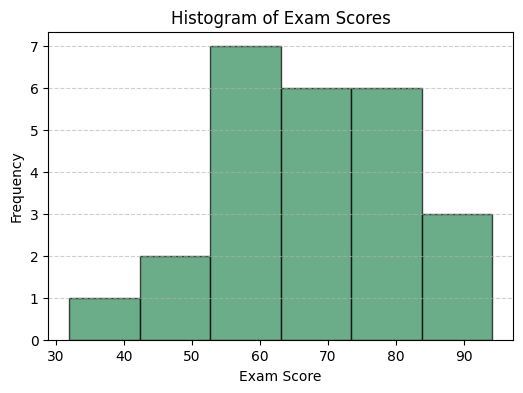

,Student_ID,Study_Hours,Attendance,Assignment_Score,Exam_Score,Z_score
0,STU001,9.5,95.0,92.0,32.0,-2.431500
1,STU002,9.6,68.0,70.2,88.2,1.466112
2,STU003,7.9,80.6,81.8,83.1,1.112415
3,STU004,6.8,83.7,82.6,77.5,0.724040
4,STU005,3.2,61.9,62.1,44.0,-1.599269


In [37]:
df["Z_score"]=(df['Exam_Score']-mean_scr)/std_scr
z_outliers = df[df['Z_score'].abs() > 2]['Student_ID'].tolist()
print(f"Students beyond 2 standard deviations: {z_outliers}")
plt.figure(figsize=(6, 4))
plt.hist(df['Exam_Score'], bins=6, color='seagreen', edgecolor='black', alpha=0.7)
plt.title('Histogram of Exam Scores')
plt.xlabel('Exam Score')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('histogram_plot.png')
plt.show()
plt.close()
df.head()


Task 6: Outlier Detection

In [38]:
iqr = q3 - q1
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr
iqr_outliers = df[(df['Exam_Score'] < lower_bound) | (df['Exam_Score'] > upper_bound)]['Student_ID'].tolist()

print("--- Task 6: Outlier Detection (IQR Method) ---")
print(f"IQR: {iqr:.2f}")
print(f"Lower Bound: {lower_bound:.2f} | Upper Bound: {upper_bound:.2f}")
print(f"Detected Outliers (IQR): {iqr_outliers}")

--- Task 6: Outlier Detection (IQR Method) ---
IQR: 19.20
Lower Bound: 29.50 | Upper Bound: 106.30
Detected Outliers (IQR): []


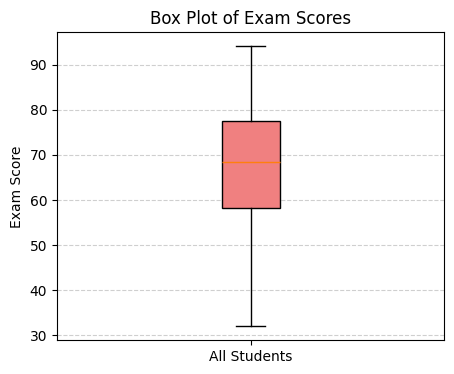

In [43]:
plt.figure(figsize=(5, 4))
plt.boxplot(df['Exam_Score'], patch_artist=True, boxprops=dict(facecolor='lightcoral'))
plt.title('Box Plot of Exam Scores')
plt.ylabel('Exam Score')
plt.xticks([1], ['All Students'])
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.savefig('box_plot.png')
plt.show()
plt.close()